# Explore recurring distant location mismatches

This notebook further analyzes coordinate mismatch cases classified as `distant_location_conflict` in the two location-review outputs (cross county and cross city reviews). 

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D

data_dir = Path('/Users/oliviakuang/Documents/GitHub/Cloudseeding2')
check_dir = data_dir / 'check'

font_path = Path('/opt/X11/share/system_fonts/Hiragino Sans GB.ttc')
if font_path.exists():
    font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# Normalize formatting differences before grouping pairs for the table
formatting_normalization = {
    # Cities
    '吉安': '吉安市',
    '抚州': '抚州市',
    '赣州': '赣州市',
    '上饶': '上饶市',

    # Counties
    '永丰': '永丰县',
    '乐安': '乐安县',
    '崇仁': '崇仁县',
    '广丰': '广丰区',
    '兴国': '兴国县',
    '永新': '永新县',
    '遂川': '遂川县',
}

def normalize_display_name(value):
    cleaned = clean_label(value)
    return formatting_normalization.get(cleaned, cleaned)

In [3]:
cross_city = pd.read_csv(check_dir / 'cross_city_location_review.csv')
cross_county = pd.read_csv(check_dir / 'cross_county_same_city_review.csv')

keep = [
    'lon', 'lat', 'records', 'first_date', 'last_date',
    'reported_city', 'reported_county',
    'coordinate_city', 'coordinate_county', 'coordinate_town',
    'tools', 'review_status',
]
distant_statuses = [
    'distant_location_conflict',
    'suspected_coordinate_issue',
]

distant = pd.concat(
    [
        cross_city.loc[
            cross_city['review_status'].isin(distant_statuses), keep
        ],
        cross_county.loc[
            cross_county['review_status'].isin(distant_statuses), keep
        ],
    ],
    ignore_index=True,
)

def clean_label(value):
    return '' if pd.isna(value) else str(value).strip()

distant['mismatch_pair'] = (
    distant['reported_city'].map(normalize_display_name) + '–'
    + distant['reported_county'].map(normalize_display_name) + ' → '
    + distant['coordinate_city'].map(normalize_display_name) + '–'
    + distant['coordinate_county'].map(normalize_display_name)
)
distant['reported_to_coordinate_county'] = (
    distant['reported_county'].map(clean_label) + ' → '
    + distant['coordinate_county'].map(clean_label)
)
distant_points = gpd.GeoDataFrame(
    distant,
    geometry=gpd.points_from_xy(distant['lon'], distant['lat']),
    crs='EPSG:4326',
)

print(f'Distant coordinate cases: {len(distant_points):,}')
print(f'Associated operation records: {distant_points["records"].sum():,}')
print(f'Directed mismatch pairs: {distant_points["mismatch_pair"].nunique():,}')

Distant coordinate cases: 27
Associated operation records: 187
Directed mismatch pairs: 18


## Coordinate-level grouped table

The table retains all 25 distant coordinate cases. Rows are grouped by the directed reported-to-coordinate-derived location pair and ordered by the pair's total number of operations. Repeated pair labels are visually suppressed only for readability; the underlying data remain unchanged.

In [4]:
location_table = distant.copy()
location_table['pair_total_records'] = (
    location_table.groupby('mismatch_pair')['records'].transform('sum')
)
location_table['coordinate'] = location_table.apply(
    lambda row: f"({row['lon']:.5f}, {row['lat']:.5f})",
    axis=1,
)
location_table['coordinate_location'] = (
    location_table['coordinate_city'].map(clean_label) + '–'
    + location_table['coordinate_county'].map(clean_label) + '–'
    + location_table['coordinate_town'].map(clean_label)
)
location_table['date_span'] = (
    location_table['first_date'].astype(str) + ' to '
    + location_table['last_date'].astype(str)
)
location_table = location_table.sort_values(
    ['pair_total_records', 'mismatch_pair', 'records', 'coordinate_location'],
    ascending=[False, True, False, True],
).reset_index(drop=True)

table_for_display = location_table[[
    'mismatch_pair', 'pair_total_records', 'coordinate_location',
    'coordinate', 'records', 'date_span', 'tools',
]].copy()
table_for_display.columns = [
    'Reported → coordinate-derived', 'Pair records',
    'Coordinate-derived location', 'Coordinate',
    'Records at coordinate', 'Date span', 'Tools',
]
table_for_display['Pair records'] = (
    table_for_display['Pair records'].astype('object')
)

same_as_previous = table_for_display[
    'Reported → coordinate-derived'
].eq(
    table_for_display['Reported → coordinate-derived'].shift()
)
table_for_display.loc[
    same_as_previous,
    ['Reported → coordinate-derived', 'Pair records'],
] = ''

styled_location_table = (
    table_for_display.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
    ])
)

try:
    display(styled_location_table)
except NameError:
    print(table_for_display.to_string(index=False))

# Quantify how concentrated the distant-conflict records are.
total_distant_records = int(distant['records'].sum())
yuehu_distant_records = int(
    distant.loc[
        distant['reported_county'].map(clean_label).eq('月湖区'),
        'records',
    ].sum()
)
lean_xiajiang_records = int(
    distant.loc[
        distant['reported_county'].map(clean_label).isin(['乐安县', '乐安'])
        & distant['coordinate_county'].map(clean_label).eq('峡江县'),
        'records',
    ].sum()
)

concentration_summary = pd.DataFrame(
    {
        'Pattern': [
            'Reported 月湖区 → other coordinate-derived counties',
            'Reported 乐安县/乐安 → coordinate-derived 峡江县',
            'Two patterns combined',
        ],
        'Distant-mismatch records': [
            yuehu_distant_records,
            lean_xiajiang_records,
            yuehu_distant_records + lean_xiajiang_records,
        ],
    }
)
concentration_summary['Share of all distant-mismatch records'] = (
    concentration_summary['Distant-mismatch records']
    / total_distant_records
)

styled_concentration_summary = (
    concentration_summary.style
    .hide(axis='index')
    .format({'Share of all distant-mismatch records': '{:.1%}'})
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
    ])
)

try:
    display(styled_concentration_summary)
except NameError:
    printable_summary = concentration_summary.copy()
    printable_summary['Share of all distant-mismatch records'] = (
        printable_summary['Share of all distant-mismatch records']
        .map('{:.1%}'.format)
    )
    print('\nConcentration of distant-mismatch records')
    print(printable_summary.to_string(index=False))

Reported → coordinate-derived,Pair records,Coordinate-derived location,Coordinate,Records at coordinate,Date span,Tools
鹰潭市–月湖区 → 鹰潭市–贵溪市,99,鹰潭市–贵溪市–龙虎山镇,"(116.96300, 28.09800)",45,2021-01-25 to 2022-10-09,烟炉
,,鹰潭市–贵溪市–塔桥园艺场,"(117.06800, 28.44900)",16,2023-01-22 to 2025-09-12,火箭弹
,,鹰潭市–贵溪市–龙虎山镇,"(116.95900, 28.09800)",12,2022-10-27 to 2025-07-18,烟炉
,,鹰潭市–贵溪市–上清镇,"(117.03300, 27.98700)",8,2024-07-28 to 2025-01-31,烟炉
,,鹰潭市–贵溪市–塔桥园艺场,"(117.08000, 28.44900)",8,2022-01-05 to 2022-08-04,火箭弹
,,鹰潭市–贵溪市–耳口乡,"(117.16000, 27.99200)",5,2024-08-04 to 2025-07-08,烟炉
,,鹰潭市–贵溪市–龙虎山镇,"(116.94200, 28.06900)",3,2022-08-10 to 2024-08-06,火箭弹
,,鹰潭市–贵溪市–上清镇,"(117.04700, 27.98700)",1,2021-06-18 to 2021-06-18,火箭弹
,,鹰潭市–贵溪市–上清镇,"(117.07400, 27.99400)",1,2025-08-27 to 2025-08-27,火箭弹
抚州市–乐安县 → 吉安市–峡江县,49,吉安市–峡江县–马埠镇,"(115.41800, 27.56800)",49,2021-02-09 to 2025-10-13,烟炉


Pattern,Distant-mismatch records,Share of all distant-mismatch records
Reported 月湖区 → other coordinate-derived counties,106,56.7%
Reported 乐安县/乐安 → coordinate-derived 峡江县,49,26.2%
Two patterns combined,155,82.9%


The distant mismatches are highly concentrated in a few recurring patterns, with the two most common patterns accounting for 85.2% of all distant mismatch records.

## Recurrence over time

The first table reports annual operation counts for the 10 largest
distant coordinate-level cases. The summary table includes all
distant mismatch cases and shows the total number of records and active
coordinate cases in each year.

In [9]:
# Link the reviewed coordinate-level cases to individual operation records.
distant_cases = distant.reset_index(drop=True).copy()
distant_cases['case_id'] = range(1, len(distant_cases) + 1)

cleaned = pd.read_csv(
    data_dir / 'intermediate/cleaned_operation.csv'
)

record_keys = ['lon', 'lat', 'county_o', 'city', 'county']
case_keys = [
    'lon', 'lat', 'reported_county',
    'coordinate_city', 'coordinate_county',
]

records = cleaned.copy()
for column in ['county_o', 'city', 'county']:
    records[column] = records[column].map(clean_label)

# Expand combined reported-county labels before matching.
# For example, "安义县 | 安义" becomes two matching rows.
distant_cases_for_match = (
    distant_cases.assign(
        reported_county=distant_cases['reported_county']
        .str.split(r'\s*\|\s*')
    )
    .explode('reported_county')
)

case_lookup = distant_cases_for_match[
    case_keys + ['case_id', 'mismatch_pair']
].copy()

for column in case_keys[2:]:
    case_lookup[column] = case_lookup[column].map(clean_label)

case_lookup = case_lookup.rename(
    columns=dict(zip(case_keys, record_keys))
)

case_lookup = case_lookup.drop_duplicates(
    subset=record_keys + ['case_id']
)

distant_records = records.merge(
    case_lookup,
    on=record_keys,
    how='inner',
    validate='many_to_one',
)

distant_records['date'] = pd.to_datetime(
    distant_records['date'],
    errors='raise',
)
distant_records['year'] = distant_records['date'].dt.year

# Confirm that every reviewed record is recovered exactly once.
expected_by_case = (
    distant_cases.set_index('case_id')['records'].astype(int)
)

matched_by_case = (
    distant_records.groupby('case_id')
    .size()
    .reindex(expected_by_case.index, fill_value=0)
)

assert len(distant_records) == expected_by_case.sum()
assert expected_by_case.eq(matched_by_case).all()

# Create readable labels for the coordinate-level cases.
case_labels = distant_cases.set_index('case_id').apply(
    lambda row: (
        f"{row['reported_county']} → "
        f"{row['coordinate_county']} | "
        f"({row['lon']:.5f}, {row['lat']:.5f})"
    ),
    axis=1,
)

# Annual counts for the ten largest coordinate-level cases.
top_case_ids = (
    distant_cases.nlargest(10, 'records')['case_id']
    .tolist()
)

yearly_by_case = (
    distant_records.loc[
        distant_records['case_id'].isin(top_case_ids)
    ]
    .groupby(['case_id', 'year'])
    .size()
    .unstack(fill_value=0)
    .reindex(top_case_ids)
)

yearly_by_case.index = yearly_by_case.index.map(case_labels)
yearly_by_case.index.name = (
    'Reported → coordinate-derived | coordinate'
)

display(
    yearly_by_case.style.background_gradient(
        cmap='Blues',
        axis=None,
    )
)

# Overall annual totals and number of active coordinate cases.
annual_summary = pd.concat(
    [
        distant_records.groupby('year')
        .size()
        .rename('Distant mismatch records'),

        distant_records.groupby('year')['case_id']
        .nunique()
        .rename('Coordinate-level cases'),
    ],
    axis=1,
)

display(annual_summary)

year,2021,2022,2023,2024,2025
Reported → coordinate-derived | coordinate,,,,,
"乐安县 → 峡江县 | (115.41800, 27.56800)",13,19,6,1,10
"月湖区 → 贵溪市 | (116.96300, 28.09800)",30,15,0,0,0
"月湖区 → 贵溪市 | (117.06800, 28.44900)",0,0,4,6,6
"月湖区 → 贵溪市 | (116.95900, 28.09800)",0,7,1,0,4
"月湖区 → 贵溪市 | (117.03300, 27.98700)",0,0,0,6,2
"月湖区 → 贵溪市 | (117.08000, 28.44900)",0,8,0,0,0
"月湖区 → 弋阳县 | (117.27600, 28.58200)",0,0,0,2,5
"信州区 → 上饶县 | (118.02600, 28.13200)",0,0,6,0,0
"上高县 → 丰城市 | (115.96100, 28.24100)",0,5,0,0,0


,Distant mismatch records,Coordinate-level cases
year,,
2020,10,6
2021,45,4
2022,65,13
2023,18,5
2024,17,6
2025,32,7


Distant mismatches appear in every year from 2020-2025. They are most frequent in 2022, when both the number of records and the number of  coordinate level cases reach peaks.

## Distribution of distant mismatches

The map shows where distant reported vs coordinate location mismatches recur across Jiangxi. Each point represents one coordinate-level case, and point size increases with the number of operation records at that exact coordinate. Colors identify the 7 reported → coordinate-derived location pairs with the most records; all remaining pairs are grouped as “Other distant mismatch.”

The left map shows all distant mismatch coordinates in Jiangxi. The right map focuses on the recurring 月湖区 → 贵溪市 pattern. 

In [11]:
townships = gpd.read_file(data_dir / 'township_shapefile/xiangzhen.shp')
townships = townships.loc[
    townships['省'].eq('江西省'),
    ['市', '县', '乡', 'geometry'],
].copy()

county_boundaries = townships.dissolve(by=['市', '县']).boundary
city_boundaries = townships.dissolve(by='市').boundary
province_boundary = townships.dissolve().boundary

yingtan_towns = townships.loc[townships['市'].astype(str).str.contains('鹰潭', na=False)].copy()
yingtan_counties = yingtan_towns.dissolve(by=['市', '县']).reset_index()

/Users/oliviakuang/Documents/GitHub/Cloudseeding2/check/distant_mismatch_recurrence_map.png


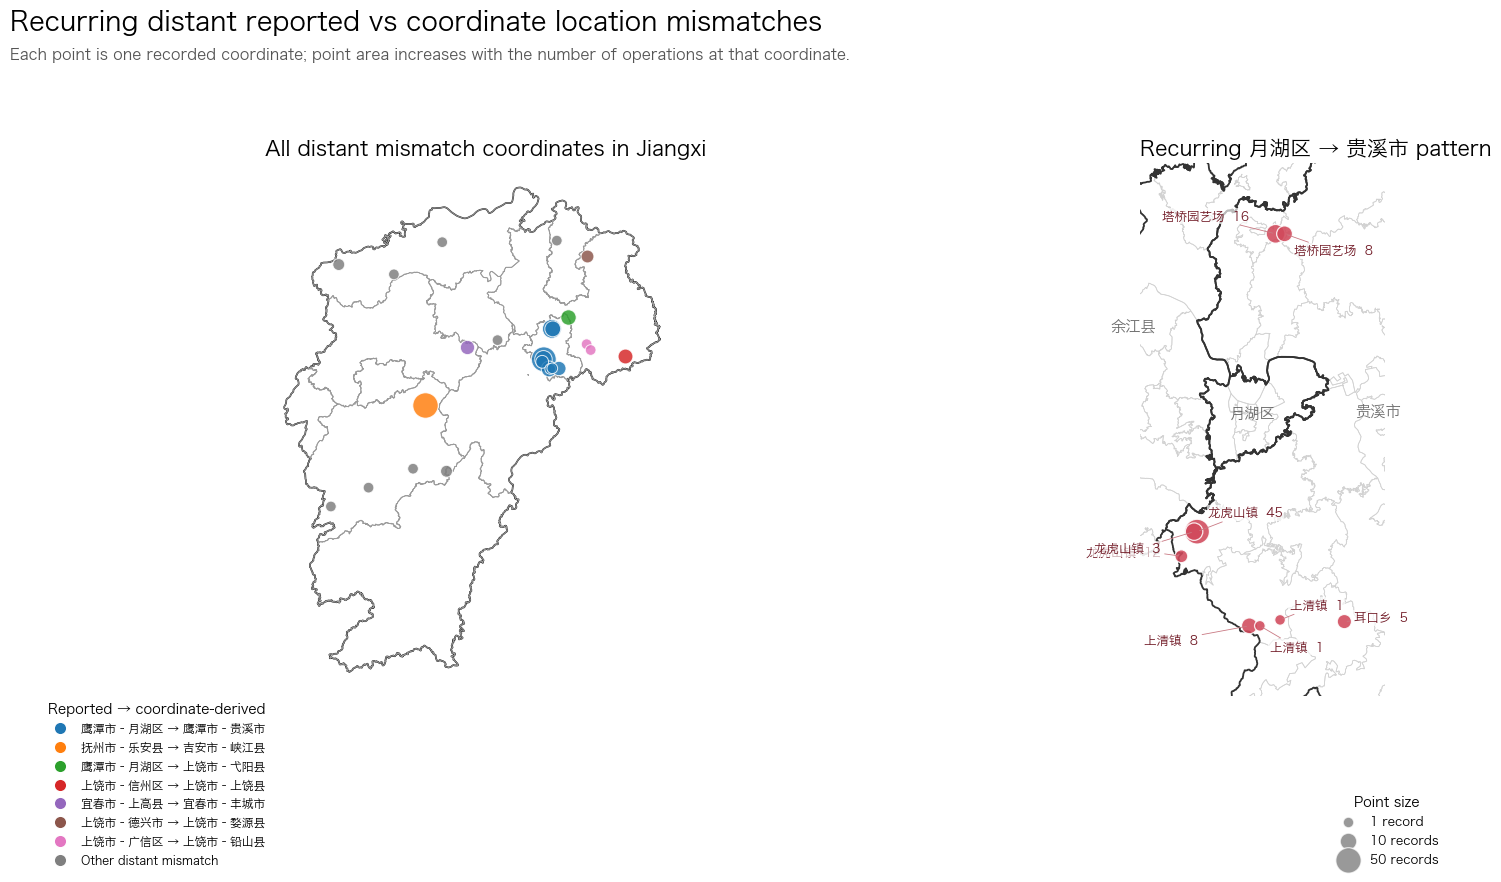

In [31]:
pair_counts = (
    distant_points.groupby('mismatch_pair')['records']
    .sum()
    .sort_values(ascending=False)
)
top_pairs = pair_counts.index[:7].tolist()
distant_points['map_pair'] = distant_points['mismatch_pair'].where(
    distant_points['mismatch_pair'].isin(top_pairs),
    'Other distant mismatch',
)

palette = list(plt.get_cmap('tab10').colors)
pair_order = top_pairs + (['Other distant mismatch'] if (distant_points['map_pair'] == 'Other distant mismatch').any() else [])
colors = {pair: palette[i % len(palette)] for i, pair in enumerate(pair_order)}

def marker_size(records):
    return 32 + 27 * (records ** 0.62)

fig, (ax_all, ax_focus) = plt.subplots(
    1, 2, figsize=(18, 9), gridspec_kw={'width_ratios': [1.05, 1]}
)

province_boundary.plot(ax=ax_all, color='#222222', linewidth=1.2)
city_boundaries.plot(ax=ax_all, color='#9a9a9a', linewidth=0.65)
for pair in pair_order:
    group = distant_points.loc[distant_points['map_pair'].eq(pair)]
    group.plot(
        ax=ax_all, color=colors[pair], edgecolor='white', linewidth=0.7,
        markersize=group['records'].map(marker_size), alpha=0.84, zorder=3,
    )
ax_all.set_title('All distant mismatch coordinates in Jiangxi', fontsize=15, loc='left')
ax_all.set_axis_off()

yingtan_towns.boundary.plot(ax=ax_focus, color='#d2d2d2', linewidth=0.55)
yingtan_counties.boundary.plot(ax=ax_focus, color='#333333', linewidth=1.3)
monthly_guixi = distant_points.loc[
    distant_points['reported_county'].astype(str).str.contains('月湖', na=False)
    & distant_points['coordinate_county'].astype(str).str.contains('贵溪', na=False)
].copy()
monthly_guixi.plot(
    ax=ax_focus, color='#d1495b', edgecolor='white', linewidth=0.9,
    markersize=monthly_guixi['records'].map(marker_size), alpha=0.88, zorder=4,
)
label_offsets = {
    (116.963, 28.098): (8, 11),
    (116.959, 28.098): (-78, -18),
    (116.942, 28.069): (-63, 3),
    (117.033, 27.987): (-76, -13),
    (117.047, 27.987): (7, -18),
    (117.074, 27.994): (7, 8),
    (117.160, 27.992): (7, 0),
    (117.068, 28.449): (-82, 10),
    (117.080, 28.449): (7, -15),
}
for row in monthly_guixi.itertuples():
    offset = label_offsets.get((round(row.lon, 3), round(row.lat, 3)), (5, 5))
    ax_focus.annotate(
        f'{row.coordinate_town}  {row.records}',
        (row.lon, row.lat), xytext=offset, textcoords='offset points',
        fontsize=9, color='#6f1723', zorder=5,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.67, 'pad': 1.1},
        arrowprops={'arrowstyle': '-', 'color': '#c97983', 'linewidth': 0.6},
    )
for row in yingtan_counties.itertuples():
    center = row.geometry.representative_point()
    ax_focus.text(
        center.x, center.y, str(row.县), ha='center', va='center',
        fontsize=11, color='#555555', alpha=0.85, zorder=2,
    )
if len(monthly_guixi):
    xmin, ymin, xmax, ymax = monthly_guixi.total_bounds
    xpad = max((xmax - xmin) * 0.20, 0.055)
    ypad = max((ymax - ymin) * 0.18, 0.045)
    ax_focus.set_xlim(xmin - xpad, xmax + xpad)
    ax_focus.set_ylim(ymin - ypad, ymax + ypad)
ax_focus.set_title('Recurring 月湖区 → 贵溪市 pattern', fontsize=15, loc='left')
ax_focus.set_axis_off()

pair_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor=colors[pair],
           markeredgecolor='white', markersize=9, label=pair)
    for pair in pair_order
]
fig.legend(
    handles=pair_handles, title='Reported → coordinate-derived',
    loc='lower left', bbox_to_anchor=(0.055, 0.015),
    frameon=False, fontsize=8.5,
)
size_values = [1, 10, 50]
size_handles = [
    plt.scatter([], [], s=marker_size(value), color='#777777', alpha=0.75,
                edgecolor='white', label=f'{value} record' + ('s' if value != 1 else ''))
    for value in size_values
]
fig.legend(
    handles=size_handles, title='Point size', loc='lower left',
    bbox_to_anchor=(0.77, 0.015), frameon=False, fontsize=9,
)
fig.suptitle('Recurring distant reported vs coordinate location mismatches', fontsize=19, x=0.04, ha='left')
fig.text(
    0.04, 0.925,
    'Each point is one recorded coordinate; point area increases with the number of operations at that coordinate.',
    fontsize=11, color='#555555',
)
plt.tight_layout(rect=[0.02, 0.20, 1, 0.90])
output_path = check_dir / 'distant_mismatch_recurrence_map.png'
fig.savefig(output_path, dpi=220, bbox_inches='tight', facecolor='white')
print(output_path)
plt.show()

### Map interpretation

Comparing with the near-boundary mismatches, distant mismatch coordinates are not very dispersed across Jiangxi: they are clustered in limited areas, with many counties containing none. The operation records are even more concentrated in a few recurring location pairs.

The largest is reported 月湖区 → coordinate-derived 贵溪市(labeled in blue), with 99 records across 9 coordinates in several parts of 贵溪市. The second largest is reported 乐安县/乐安 → coordinate-derived 峡江县(orange), with all 49 records occurring at 1 single coordinate.

#### Note on the 月湖区 → 贵溪市 close-up

The close-up map shows that the distant mismatch coordinates reported as `月湖区` are dispersed across several parts of coordinate-derived `贵溪市`. However, it is not very informative for assessing potential selection bias from dropping distant mismatches. The close-up also excludes the separate `near_boundary_review` mismatches.

## Potential attrition problem from removing distant mismatches

This table checks how excluding all distant mismatch records would change our coordinate-based sample.

In [13]:
# Count all operation records by coordinate-derived county.
all_county_records = (
    cleaned['county']
    .map(clean_label)
    .value_counts()
    .rename('All operation records')
)

# Count distant mismatch records by coordinate-derived county.
distant_county_records = (
    distant_records['county']
    .map(clean_label)
    .value_counts()
    .rename('Distant mismatch records')
)

spatial_attrition = pd.concat(
    [
        all_county_records,
        distant_county_records,
    ],
    axis=1,
).fillna(0)

spatial_attrition[
    ['All operation records', 'Distant mismatch records']
] = spatial_attrition[
    ['All operation records', 'Distant mismatch records']
].astype(int)

# Keep only counties affected by distant-mismatch exclusion.
spatial_attrition = spatial_attrition.loc[
    spatial_attrition['Distant mismatch records'].gt(0)
].copy()

spatial_attrition['Share excluded'] = (
    spatial_attrition['Distant mismatch records']
    / spatial_attrition['All operation records']
)

# Show counties with the most excluded records first.
spatial_attrition = spatial_attrition.sort_values(
    ['Distant mismatch records', 'Share excluded'],
    ascending=[False, False],
)

spatial_attrition.index.name = 'Coordinate-derived county'

display(
    spatial_attrition.style
    .format({'Share excluded': '{:.1%}'})
    .set_caption(
        'Spatial attrition from excluding distant mismatches'
    )
)

,All operation records,Distant mismatch records,Share excluded
Coordinate-derived county,,,
贵溪市,237,99,41.8%
峡江县,102,49,48.0%
弋阳县,141,7,5.0%
上饶县,179,6,3.4%
丰城市,87,5,5.7%
吉水县,107,4,3.7%
婺源县,65,3,4.6%
铅山县,99,2,2.0%
修水县,211,2,0.9%


### Interpretation

Excluding distant mismatches would affect coordinate-derived counties
unevenly. The largest effects are in 峡江县 and 贵溪市:

- **峡江县:** 49 of 102 coordinate-assigned operations would be removed
  (48.0%). All 49 are reported as 乐安县 / 乐安 and occur at the same exact
  coordinate in 马埠镇.
- **贵溪市:** 99 of 237 coordinate-assigned operations would be removed
  (41.8%). These records are part of the recurring reported 月湖区 →
  coordinate-derived 贵溪市 pattern.

The effect is much smaller in the other coordinate-derived counties.

### Reported locations associated with the largest reductions

- The reduction in 贵溪市 is mostly linked with records reported as
  月湖区.
- The reduction in 峡江县 is linked with 49 records reported as
  乐安县 / 乐安 at one same coordinate.